In [16]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TRAIN_DATA  = '../../data/processed/combined_hourly_regional_train.csv'
TEST_DATA   = '../../data/processed/combined_hourly_regional_test.csv'
SCALER_PATH = '../../data/processed/combined_hourly_regional_scaler.json'

STATIONS     = ['sacramento', 'sanjose', 'fresno', 'la']
WEATHER_VARS = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct']
WEATHER_COLS = [f'{s}_{v}' for s in STATIONS for v in WEATHER_VARS]

OTHER_FEATURES = ['gas_price_mmbtu', 'is_holiday', 'is_weekend',
                  'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

FEATURES     = WEATHER_COLS + OTHER_FEATURES
LAG_FEATURES = FEATURES + [f'load_lag{i}' for i in range(1, 25)]

TARGET = 'load_mw'

### 1. Load pre-engineered data

In [17]:
train = pd.read_csv(TRAIN_DATA, parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(TEST_DATA,  parse_dates=['datetime'], index_col='datetime')

with open(SCALER_PATH) as f:
    scaler = json.load(f)
load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']

print(f'Train: {len(train):,}  {train.index[0].date()} to {train.index[-1].date()}')
print(f'Test:  {len(test):,}   {test.index[0].date()} to {test.index[-1].date()}')
print(f'load_mw  mean={load_mean:.1f} MW  std={load_std:.1f} MW  (train only)')
print(f'{len(LAG_FEATURES)} input features')

Train: 42,076  2019-01-02 to 2023-10-20
Test:  10,519   2023-10-20 to 2024-12-31
load_mw  mean=25225.2 MW  std=4789.3 MW  (train only)
53 input features


### 2. Build feature arrays

In [18]:
X_train_base, X_test_base = train[FEATURES],     test[FEATURES]
X_train_lag,  X_test_lag  = train[LAG_FEATURES], test[LAG_FEATURES]
y_train, y_test            = train[TARGET],       test[TARGET]

### 3. Fit & evaluate

In [19]:
def evaluate(name, model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    print(f'{name}')
    print(f'  RMSE  {rmse:.4f}  ({rmse * load_std:.0f} MW)')
    print(f'  MAE   {mae:.4f}  ({mae  * load_std:.0f} MW)')
    print(f'  R2    {r2:.4f}')
    print()
    return pred

lr_base = LinearRegression().fit(X_train_base, y_train)
lr_lag  = LinearRegression().fit(X_train_lag,  y_train)

pred_base = evaluate('Linear Regression Regional (no lags)',   lr_base, X_test_base, y_test)
pred_lag  = evaluate('Linear Regression Regional (with lags)', lr_lag,  X_test_lag,  y_test)

Linear Regression Regional (no lags)
  RMSE  0.5134  (2459 MW)
  MAE   0.4019  (1925 MW)
  R2    0.7205

Linear Regression Regional (with lags)
  RMSE  0.1050  (503 MW)
  MAE   0.0793  (380 MW)
  R2    0.9883



### 4. Predictions vs actuals (first 2 weeks of test)

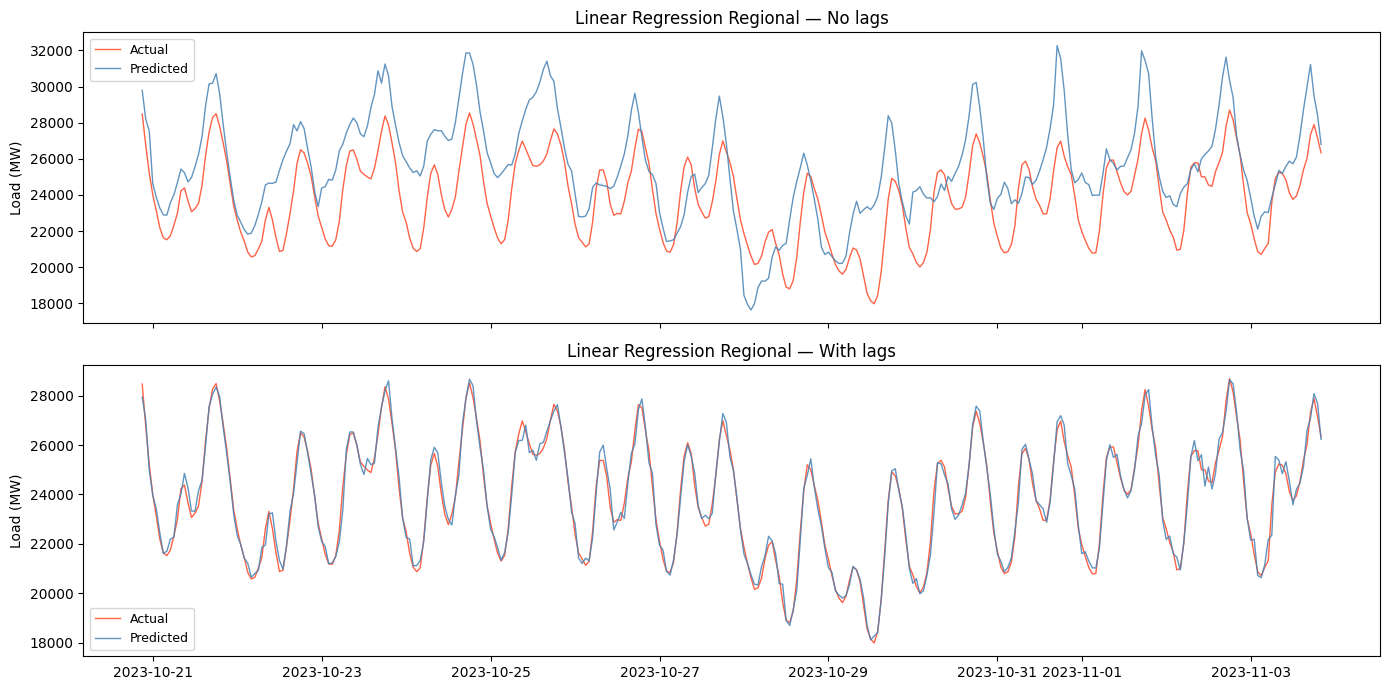

In [20]:
n      = 24 * 14
idx    = test.index[:n]
actual = y_test.values[:n] * load_std + load_mean

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, pred, label in zip(axes, [pred_base[:n], pred_lag[:n]], ['No lags', 'With lags']):
    ax.plot(idx, actual,                      color='tomato',    linewidth=1,        label='Actual')
    ax.plot(idx, pred * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='Predicted')
    ax.set_ylabel('Load (MW)')
    ax.set_title(f'Linear Regression Regional — {label}')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 5. Feature coefficients (lag model)

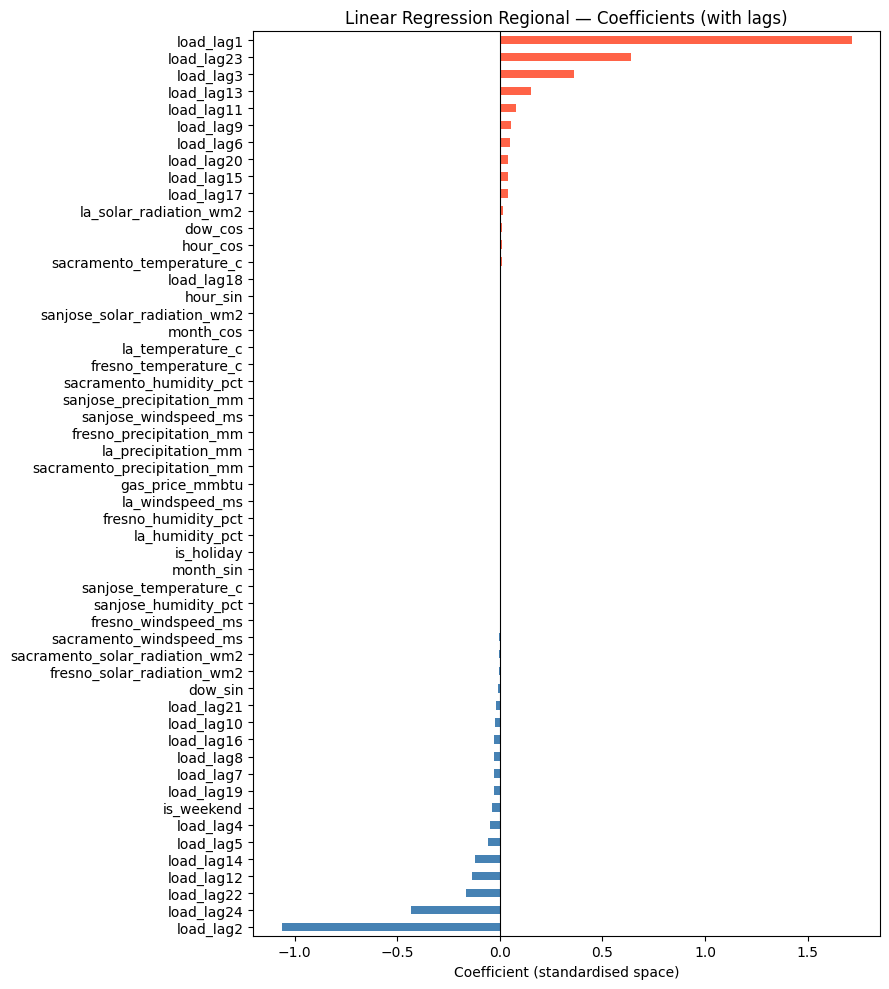

In [21]:
coef = pd.Series(lr_lag.coef_, index=LAG_FEATURES).sort_values()
colors = ['tomato' if c > 0 else 'steelblue' for c in coef]

fig, ax = plt.subplots(figsize=(9, 10))
coef.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression Regional — Coefficients (with lags)')
ax.set_xlabel('Coefficient (standardised space)')
plt.tight_layout()
plt.show()